In [ ]:
#Import necessary libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy, skew, kurtosis
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split,StratifiedKFold, cross_validate, cross_val_predict
from sklearn.feature_selection import VarianceThreshold,SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier, Pool
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc, roc_curve, make_scorer
from sklearn.feature_selection import mutual_info_classif
import optuna
import shap


## 1. Load data & preprocess data

In [850]:
# Load dataset
df = pd.read_csv("C:/Users/Anh Thu/Downloads/Master/Customer Data/Assignment_data.csv")

In [851]:
df.head()

,device,score,time
0,352610060979119,7,1421157320
1,352610060979119,0,1421157288
2,352610060979119,6,1421157344
3,99000072289368,106,1421163166
4,357470044931974,278,1421163783


In [852]:
# Check missing values
missing_values_count = df.isnull().sum()
print("Before dropping missing value:", missing_values_count)

# Drop missing value in Devide column
df['device'] = df['device'].replace(["", " "], np.nan)
df = df.dropna(subset=['device'])

print("After dropping missing value:", df.isnull().sum())

Before dropping missing value: device    9
score     0
time      0
dtype: int64
After dropping missing value: device    0
score     0
time      0
dtype: int64


In [853]:
# Convert Unix time to datetime format
df['converted_time'] = pd.to_datetime(df['time'], unit='s', origin='unix')

# Split datetime into separate date and time columns
df['date'] = df['converted_time'].dt.date  # extract date
df['time_hr'] = df['converted_time'].dt.strftime('%H:%M:%S')  # extract time in HH:MM:SS format
df['hour_of_day'] = df['converted_time'].dt.hour
df['day_of_week'] = df['converted_time'].dt.day_name()
df['month'] = df['converted_time'].dt.month
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int) # Weekend=1, weekday=0
df['is_night'] = df['hour_of_day'].isin([0, 1, 2, 3, 4, 5, 22, 23]).astype(int) # Night=1, day=0
df.head()

,device,score,time,converted_time,date,time_hr,hour_of_day,day_of_week,month,is_weekend,is_night
0,352610060979119,7,1421157320,2015-01-13 13:55:20,2015-01-13,13:55:20,13,Tuesday,1,0,0
1,352610060979119,0,1421157288,2015-01-13 13:54:48,2015-01-13,13:54:48,13,Tuesday,1,0,0
2,352610060979119,6,1421157344,2015-01-13 13:55:44,2015-01-13,13:55:44,13,Tuesday,1,0,0
3,99000072289368,106,1421163166,2015-01-13 15:32:46,2015-01-13,15:32:46,15,Tuesday,1,0,0
4,357470044931974,278,1421163783,2015-01-13 15:43:03,2015-01-13,15:43:03,15,Tuesday,1,0,0


## 2. Exploratory Data Analysis

In [686]:
# Count unique device values, which are unique players
unique_device_count = df['device'].nunique()
print("Number of unique device values:", unique_device_count)

Number of unique device values: 25956


### 2.1 Time Analysis

In [687]:
# Date range in the dataset
earliest_date = df['converted_time'].min().date()
latest_date = df['converted_time'].max().date()
print("Earliest date:", earliest_date)
print("Latest date:", latest_date)

Earliest date: 2015-01-13
Latest date: 2016-05-24


Player Lifetime Distribution:
count    25956.000000
mean         9.061219
std         39.746446
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
90%         11.000000
95%         45.000000
99%        232.000000
max        480.000000
Name: lifetime_days, dtype: float64


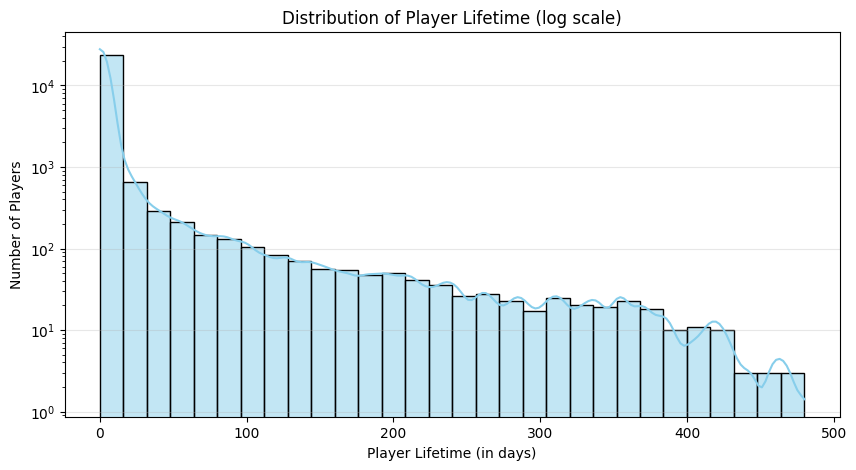

In [688]:
# Player lifetime analysis
player_lifetime = df.groupby('device').agg(first_session=('converted_time', 'min'),last_session=('converted_time', 'max'),
    total_sessions=('score', 'count')).reset_index()
player_lifetime['lifetime_days'] = (player_lifetime['last_session'] - player_lifetime['first_session']).dt.days

print("Player Lifetime Distribution:")
print(player_lifetime['lifetime_days'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
# Visualization 
plt.figure(figsize=(10, 5))
sns.histplot(player_lifetime['lifetime_days'], bins=30, kde=True, color='skyblue')
plt.yscale('log')
plt.xlabel('Player Lifetime (in days)')
plt.ylabel('Number of Players')
plt.title('Distribution of Player Lifetime (log scale)')
plt.grid(axis='y', alpha=0.3)
plt.show()

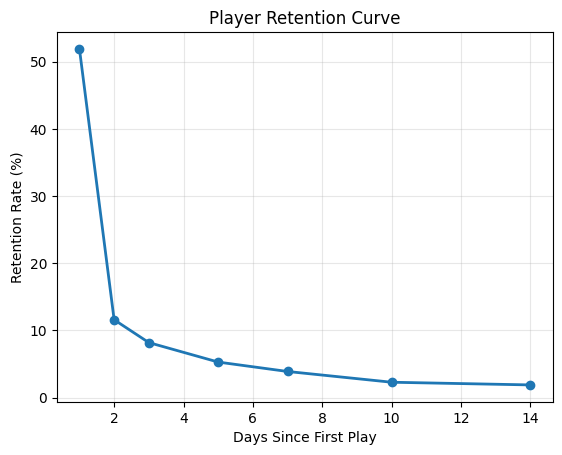

Retention Rate:
   Day  Retention_Rate
0    1           0.519
1    2           0.116
2    3           0.082
3    5           0.053
4    7           0.039
5   10           0.023
6   14           0.019
7   21           0.013


In [858]:
# Rentention rate - How many percentages of players come back after N days?
def retention_rate(df):
    df = df.copy()
    df['converted_time'] = pd.to_datetime(df['converted_time'])

    player_sessions = df.groupby('device')['converted_time'].apply(list).reset_index()

    retention_data = []

    for N in [1, 2, 3, 5, 7, 10, 14, 21]:
        retained = 0
        for sessions in player_sessions['converted_time']:
            sessions = sorted(sessions)
            first = sessions[0]
            returned = any(abs((s - first).days - N) <= 1 for s in sessions[1:])
            if returned:
                retained += 1
        
        rate = round(retained / len(player_sessions), 3)
        retention_data.append({'Day': N, 'Retention_Rate': rate})
    
    return pd.DataFrame(retention_data)
retention_df = retention_rate(df)

# Visualization
special_days = [1, 2, 3, 5, 7, 10, 14]
subset = retention_df[retention_df['Day'].isin(special_days)]
plt.plot(subset['Day'],subset['Retention_Rate'] * 100, marker='o', linewidth=2)
plt.xlabel('Days Since First Play')
plt.ylabel('Retention Rate (%)')
plt.title('Player Retention Curve')
plt.grid(alpha=0.3)
plt.show()

print("Retention Rate:")
print(retention_df)

### 2.2 Score Analysis

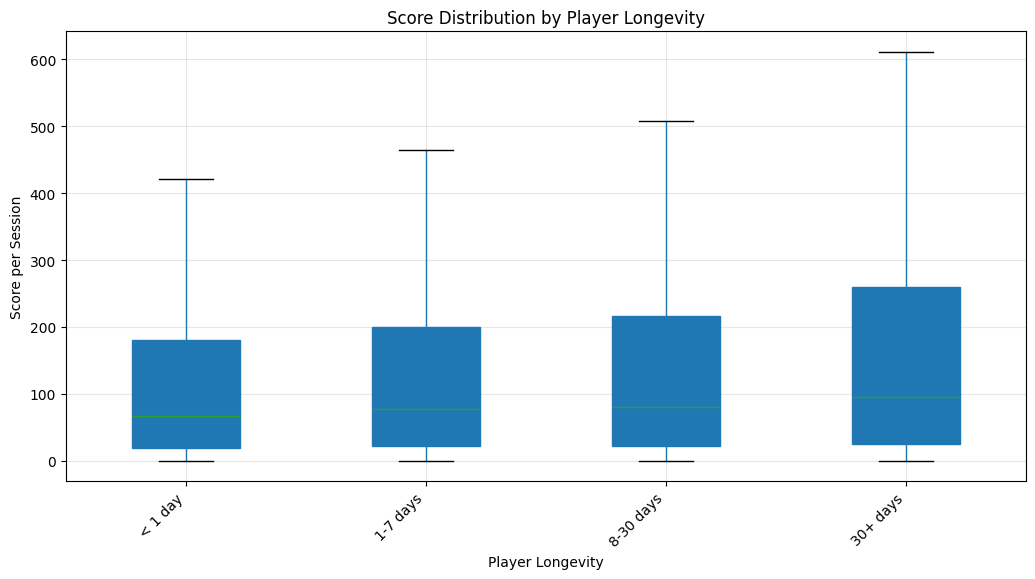

Mean Scores by Longevity:
                 mean  median         std
longevity                                
< 1 day    170.670992    67.0  397.108180
1-7 days   188.484247    77.0  438.368089
8-30 days  196.322240    81.0  449.597353
30+ days   233.387821    95.0  477.780575


C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_7092\2148423583.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_with_lifetime.groupby('longevity')['score'].agg(['mean', 'median', 'std']))


In [690]:
# Score Distribution by Player Longevity
df_with_lifetime = df.merge(player_lifetime[['device', 'lifetime_days', 'total_sessions']], on='device')

# Categorize by lifetime
df_with_lifetime['longevity'] = pd.cut(df_with_lifetime['lifetime_days'],bins=[0, 1, 7, 30, np.inf],
    labels=['< 1 day', '1-7 days', '8-30 days', '30+ days'])

# Boxplot comparison
plt.figure(figsize=(12, 6))
df_with_lifetime.boxplot(column='score', by='longevity', ax=plt.gca(), patch_artist=True, showfliers=False)
plt.suptitle('')  # Remove default title
plt.title('Score Distribution by Player Longevity')
plt.xlabel('Player Longevity')
plt.ylabel('Score per Session')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.show()

# Statistical test
print("Mean Scores by Longevity:")
print(df_with_lifetime.groupby('longevity')['score'].agg(['mean', 'median', 'std']))

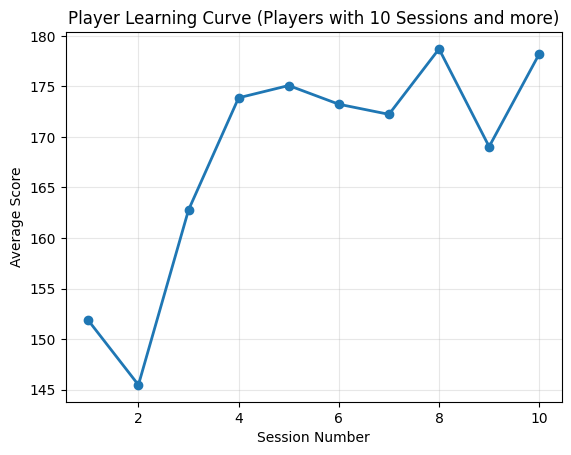

In [691]:
# Check score trend of player who play more than 10 sessions
session_counts = df['device'].value_counts()
df_10 = df[df['device'].isin(session_counts[session_counts >= 10].index)]

# Take first 10 sessions ONLY for players with >= 10 sessions
first_sessions = df_10.groupby('device').head(10).copy()

# Assign session numbers 1–10
first_sessions['session_number'] = first_sessions.groupby('device').cumcount() + 1

# Compute mean score per session number
learning_curve = (first_sessions.groupby('session_number')['score'] .mean().reset_index())

plt.plot(learning_curve['session_number'],learning_curve['score'],marker='o', linewidth=2)
plt.xlabel('Session Number')
plt.ylabel('Average Score')
plt.title('Player Learning Curve (Players with 10 Sessions and more)')
plt.grid(alpha=0.3)
plt.show()

In [692]:
# Percentage of zero scores per player
zero_score_pct = df.groupby('device')['score'].apply(lambda x: (x == 0).mean()).reset_index()
zero_score_pct.columns = ['device', 'zero_pct']

# Merge with lifetime
zero_score_pct = zero_score_pct.merge(player_lifetime[['device', 'lifetime_days']], on='device')
zero_score_pct['churned'] = (zero_score_pct['lifetime_days'] <= 7).astype(int)

print("\nZero Score Analysis:")
print(zero_score_pct.groupby('churned')['zero_pct'].describe())


Zero Score Analysis:
           count      mean       std  min  25%  50%       75%  max
churned                                                           
0         2913.0  0.026058  0.067813  0.0  0.0  0.0  0.017544  0.5
1        23043.0  0.026856  0.127376  0.0  0.0  0.0  0.000000  1.0


### 2.3 Session Analysis

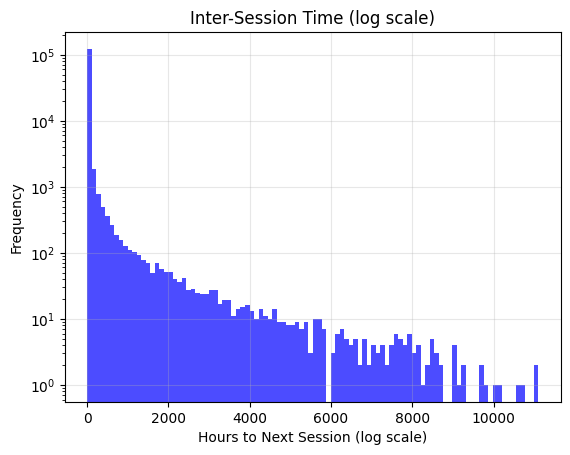


Inter-Session Time Analysis:
count    127964.000000
mean         44.755968
std         355.189708
min           0.000000
25%           0.007500
50%           0.015278
75%           0.060000
90%          20.912861
95%          87.611972
99%        1133.941414
max       11096.131389
Name: time_to_next_hours, dtype: float64


In [693]:
# Inter-Session Time (time between sessions for the same player)

df_sorted = df.sort_values(['device', 'converted_time'])
df_sorted['time_to_next'] = df_sorted.groupby('device')['converted_time'].shift(-1)
df_sorted['time_to_next_hours'] = (df_sorted['time_to_next'] - df_sorted['converted_time']).dt.total_seconds() / 3600

# Remove one time player
inter_session = df_sorted.dropna(subset=['time_to_next_hours'])

# Visualization: Distribution with log scale
plt.hist(inter_session['time_to_next_hours'], bins=100, alpha=0.7, color='blue')
plt.xlabel('Hours to Next Session (log scale)')
plt.ylabel('Frequency')
plt.title('Inter-Session Time (log scale)')
plt.yscale('log') # Normal scale doesn't show distribution well
plt.grid(alpha=0.3)
plt.show()

# Key percentiles
print("\nInter-Session Time Analysis:")
print(inter_session['time_to_next_hours'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

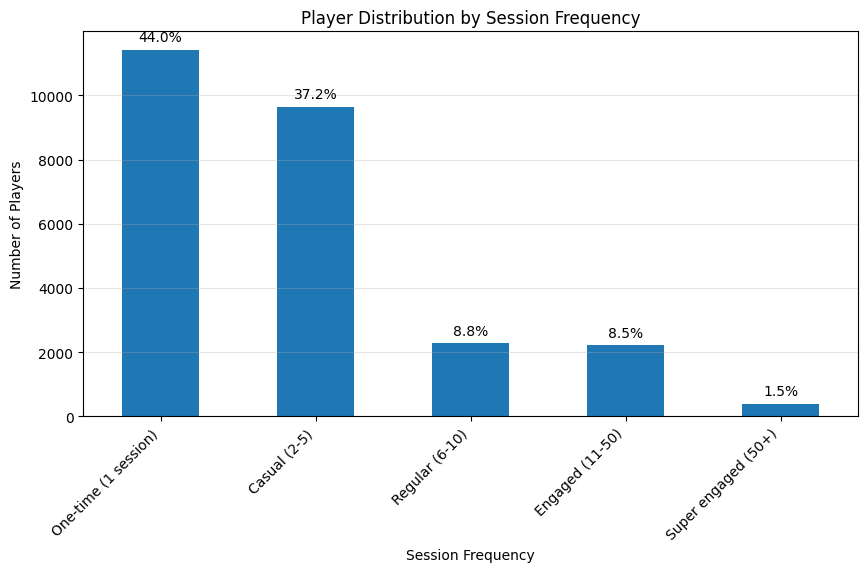


Session Frequency Distribution:
session_frequency
One-time (1 session)    0.440052
Casual (2-5)            0.371860
Regular (6-10)          0.087725
Engaged (11-50)         0.085260
Super engaged (50+)     0.015102
Name: proportion, dtype: float64


In [694]:
# Session Frequency
session_counts = df.groupby('device').size().reset_index(name='session_count')
session_counts['session_frequency'] = pd.cut(
    session_counts['session_count'],
    bins=[0, 1, 5, 10, 50, np.inf],
    labels=['One-time (1 session)', 'Casual (2-5)', 'Regular (6-10)', 'Engaged (11-50)', 'Super engaged (50+)']
)

# Visualization
plt.figure(figsize=(10, 5))
session_counts['session_frequency'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Session Frequency')
plt.ylabel('Number of Players')
plt.title('Player Distribution by Session Frequency')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
total = len(session_counts)
for i, v in enumerate(session_counts['session_frequency'].value_counts().sort_index()):
    plt.text(i, v + total*0.01, f'{v/total*100:.1f}%', ha='center')

plt.show()

print("\nSession Frequency Distribution:")
print(session_counts['session_frequency'].value_counts(normalize=True).sort_index())

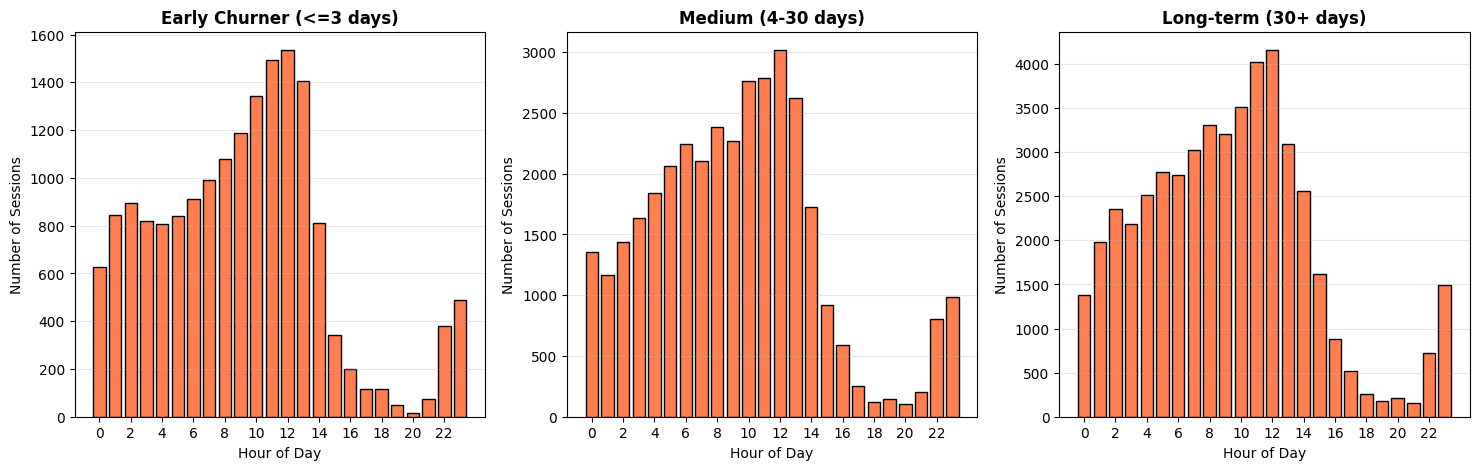

In [695]:
# Hour of Day Analysis
hourly_data = df.merge(player_lifetime[['device', 'lifetime_days']], on='device')
hourly_data['player_category'] = pd.cut(hourly_data['lifetime_days'],bins=[0, 3, 30, np.inf],
    labels=['Early Churner (<=3 days)', 'Medium (4-30 days)', 'Long-term (30+ days)'])

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, category in enumerate(['Early Churner (<=3 days)', 'Medium (4-30 days)', 'Long-term (30+ days)']):
    ax = axes[idx]
    data = hourly_data[hourly_data['player_category'] == category]
    
    hour_dist = data['hour_of_day'].value_counts().sort_index()
    ax.bar(hour_dist.index, hour_dist.values, color='coral', edgecolor='black')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Number of Sessions')
    ax.set_title(category,fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticks(range(0, 24, 2))

plt.show()

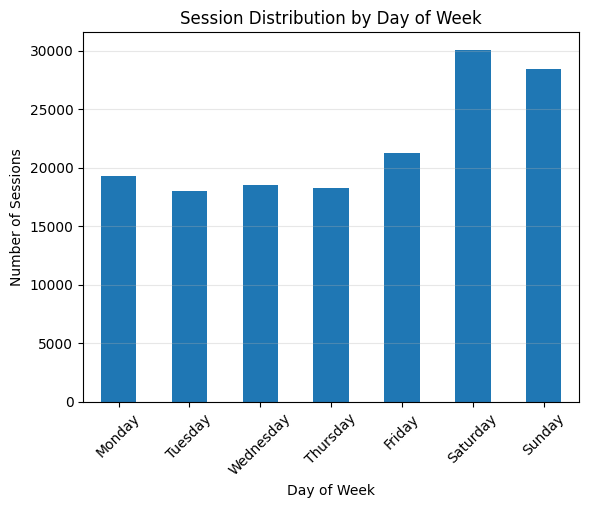

In [696]:
# Define order for days of the week
df['day_of_week'] = df['converted_time'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=days_order, ordered=True)

day_dist = df['day_of_week'].value_counts().sort_index()
#Visualization
day_dist.plot(kind='bar')
plt.xlabel('Day of Week')
plt.ylabel('Number of Sessions')
plt.title('Session Distribution by Day of Week')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

## 3. Create churn and no-churn label

In [981]:
def create_churn_labels(df, OP_days, CP_days):
    # Find each player's t0 (first play)
    t0 = df.groupby('device')['converted_time'].min().rename('t0')

    # create windows (OP and CP)
    windows = t0.reset_index().copy()
    windows['OP_start'] = windows['t0']
    windows['OP_end'] = windows['t0'] + pd.Timedelta(days=OP_days)
    windows['CP_end'] = windows['OP_end'] + pd.Timedelta(days=CP_days)
    # Merge to assign sessions to windows
    tmp = df.merge(windows[['device','OP_start','OP_end','CP_end']], on='device', how='left')
    tmp['in_OP'] = (tmp['converted_time'] >= tmp['OP_start']) & (tmp['converted_time'] < tmp['OP_end'])
    tmp['in_CP'] = (tmp['converted_time'] >= tmp['OP_end']) & (tmp['converted_time'] < tmp['CP_end'])

    # churn label per device
    counts = tmp.groupby('device').agg(op_sessions=('in_OP','sum'), cp_sessions=('in_CP','sum')).reset_index()
    counts['churn'] = np.where((counts['op_sessions']>=1) & (counts['cp_sessions']==0), 1,
                    np.where((counts['op_sessions']>=1) & (counts['cp_sessions']>0), 0, np.nan))
    counts = counts.dropna(subset=['churn'])
    return windows, counts


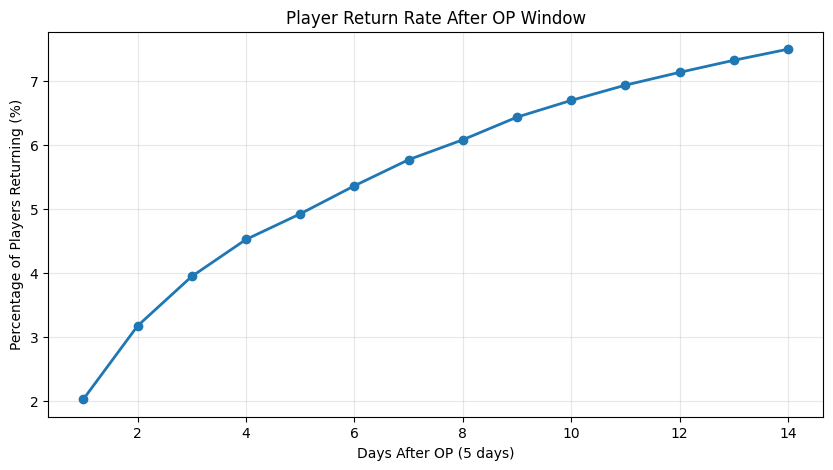

Return Rate Statistics After OP Window:
count    14.000000
mean      0.055605
std       0.016646
min       0.020227
25%       0.046232
50%       0.059273
75%       0.068789
max       0.075012
Name: Return_Rate, dtype: float64
Return Rate Statistics After OP Window:
count | Value: 14.000000 | Day: 
mean  | Value: 0.055605 | Day: 
std   | Value: 0.016646 | Day: 
min   | Value: 0.020227 | Day: 1
25%   | Value: 0.046232 | Day: 5
50%   | Value: 0.059273 | Day: 8
75%   | Value: 0.068789 | Day: 11
max   | Value: 0.075012 | Day: 14


In [982]:
# Analyze return after OP period
def return_after_OP(df, OP_days=5, max_days=14):
    # Group sessions by player
    player_sessions = df.groupby('device')['converted_time'].apply(list).reset_index()
    return_data = []
    for day in range(1, max_days + 1):
        returned = 0
        for idx, row in player_sessions.iterrows():
            sessions = sorted(row['converted_time'])
            first_session = sessions[0]
            # Only consider sessions after OP_days
            future_sessions = [s for s in sessions if (s - first_session).days > OP_days]
            # Check if player came back within 'day' days after OP_days
            if any((s - first_session).days <= OP_days + day for s in future_sessions):
                returned += 1
        return_rate = returned / len(player_sessions)
        return_data.append({'Days_After_OP': day, 'Return_Rate': return_rate})
    
    return pd.DataFrame(return_data)

# Run analysis
ret_after_op_df = return_after_OP(df, OP_days=5, max_days=14)

# Plot cumulative return rate
plt.figure(figsize=(10, 5))
plt.plot(ret_after_op_df['Days_After_OP'], ret_after_op_df['Return_Rate']*100, marker='o', linewidth=2)
plt.xlabel('Days After OP (5 days)')
plt.ylabel('Percentage of Players Returning (%)')
plt.title('Player Return Rate After OP Window')
plt.grid(alpha=0.3)
plt.show()

return_stats = ret_after_op_df['Return_Rate'].describe(percentiles=[0.25, 0.5, 0.75])
print("Return Rate Statistics After OP Window:")
print(return_stats)

# Statistics
stats = ret_after_op_df['Return_Rate'].describe(percentiles=[0.25, 0.5, 0.75])
print("Return Rate Statistics After OP Window:")

# Add day corresponding to each statistic
day_for_stat = {
    'min': ret_after_op_df.loc[ret_after_op_df['Return_Rate'].idxmin(), 'Days_After_OP'],
    '25%': ret_after_op_df.loc[(ret_after_op_df['Return_Rate'] >= stats['25%']).idxmax(), 'Days_After_OP'],
    '50%': ret_after_op_df.loc[(ret_after_op_df['Return_Rate'] >= stats['50%']).idxmax(), 'Days_After_OP'],
    '75%': ret_after_op_df.loc[(ret_after_op_df['Return_Rate'] >= stats['75%']).idxmax(), 'Days_After_OP'],
    'max': ret_after_op_df.loc[ret_after_op_df['Return_Rate'].idxmax(), 'Days_After_OP']
}

# Print statistics with days
for stat in ['count','mean','std','min','25%','50%','75%','max']:
    value = stats[stat] if stat in stats else None
    day = day_for_stat[stat] if stat in day_for_stat else ''
    print(f"{stat:5s} | Value: {value:.6f} | Day: {day}")



In [983]:
# Create churn labels with OP=5 days and CP=10 days
OP_days = 5
CP_days = 10
windows, counts = create_churn_labels(df, OP_days, CP_days)

In [984]:
# Check churn distribution
print("Churn distribution:")
print(counts['churn'].value_counts(dropna=False))

print("\nProportion:")
print(counts['churn'].value_counts(normalize=True, dropna=False))

Churn distribution:
churn
1.0    24028
0.0     1928
Name: count, dtype: int64

Proportion:
churn
1.0    0.92572
0.0    0.07428
Name: proportion, dtype: float64


In [985]:
# Merge with churn labels
windows = windows.merge(counts[['device', 'churn']], on='device', how='left')

In [986]:
windows.head()

,device,t0,OP_start,OP_end,CP_end,churn
0,0,2015-04-11 11:52:38,2015-04-11 11:52:38,2015-04-16 11:52:38,2015-04-26 11:52:38,1.0
1,000000000000000,2015-01-23 02:04:44,2015-01-23 02:04:44,2015-01-28 02:04:44,2015-02-07 02:04:44,1.0
2,010941525590041,2015-07-07 10:33:00,2015-07-07 10:33:00,2015-07-12 10:33:00,2015-07-22 10:33:00,1.0
3,012345678901237,2015-02-23 03:24:43,2015-02-23 03:24:43,2015-02-28 03:24:43,2015-03-10 03:24:43,1.0
4,012345678912345,2015-02-22 08:51:46,2015-02-22 08:51:46,2015-02-27 08:51:46,2015-03-09 08:51:46,1.0


## 4. Feature Engineering

In [1026]:
def features_engineer(df, windows, OP_days):
    # Filter for OP sessions only
    tmp = df.merge(windows[['device','OP_start','OP_end','CP_end']], on='device', how='left')
    tmp['in_OP'] = (tmp['converted_time'] >= tmp['OP_start']) & (tmp['converted_time'] < tmp['OP_end'])
    df_OP = tmp[tmp['in_OP'] == True].copy()
    # Basic statistics
    features = df_OP.groupby('device').agg(
        total_sessions=('score', 'count'),
        total_score=('score', 'sum'),
        avg_score=('score', 'mean'),
        max_score=('score', 'max'),
        min_score=('score', 'min'),
        median_score=('score', 'median'),
        std_score=('score', 'std'),
        first_play=('converted_time', 'min'), 
        last_play=('converted_time', 'max')
    ).reset_index()
    
    # Score distribution features    
    features['score_range'] = features['max_score'] - features['min_score']
    features['score_cv'] = features['std_score'] / (features['avg_score'] + 1)  # coefficient of variation
    
    score_skew = df_OP.groupby('device')['score'].apply(
        lambda x: skew(x) if len(x) > 2 else 0
    ).rename('score_skewness')
    features = features.merge(score_skew.reset_index(), on='device', how='left')
    
    score_kurt = df_OP.groupby('device')['score'].apply(
        lambda x: kurtosis(x) if len(x) > 2 else 0
    ).rename('score_kurtosis')
    features = features.merge(score_kurt.reset_index(), on='device', how='left')
    
    def calculate_entropy(scores):
        if len(scores) < 2:
            return 0
        value_counts = pd.Series(scores).value_counts(normalize=True)
        return entropy(value_counts)
    
    score_entropy = df_OP.groupby('device')['score'].apply(calculate_entropy).rename('score_entropy')
    features = features.merge(score_entropy.reset_index(), on='device', how='left')
    
    score_75 = df_OP['score'].quantile(0.75)
    high_score_pct = df_OP.groupby('device')['score'].apply(
        lambda x: (x > score_75).mean()
    ).rename('high_score_pct')
    features = features.merge(high_score_pct.reset_index(), on='device', how='left')
    
    # Session patterns features    
    features['activity_days'] = (features['last_play'] - features['first_play']).dt.days + 1
    features['sessions_per_day'] = features['total_sessions'] / features['activity_days']
    features['score_per_session'] = features['total_score'] / features['total_sessions']
    features['session_span_days'] = (features['last_play'] - features['first_play']).dt.total_seconds() / (3600 * 24)

    # Inter-session patterns features
    def calc_mean_interval(group):
        times = group.sort_values()
        if len(times) <= 1:
            return 0
        intervals = times.diff().dropna().dt.total_seconds() / 3600
        return intervals.mean()
    
    def calc_median_interval(group):
        times = group.sort_values()
        if len(times) <= 1:
            return 0
        intervals = times.diff().dropna().dt.total_seconds() / 3600
        return intervals.median()
    
    def calc_interval_cv(group):
        times = group.sort_values()
        if len(times) <= 1:
            return 0
        intervals = times.diff().dropna().dt.total_seconds() / 3600
        if intervals.mean() == 0 or intervals.std() == 0:
            return 0
        return intervals.std() / intervals.mean()
    
    mean_interval = df_OP.groupby('device')['converted_time'].apply(calc_mean_interval).rename('mean_interval_hours')
    features = features.merge(mean_interval.reset_index(), on='device', how='left')
    
    median_interval = df_OP.groupby('device')['converted_time'].apply(calc_median_interval).rename('median_interval_hours')
    features = features.merge(median_interval.reset_index(), on='device', how='left')
    
    interval_cv = df_OP.groupby('device')['converted_time'].apply(calc_interval_cv).rename('interval_cv')
    features = features.merge(interval_cv.reset_index(), on='device', how='left')
    
    # Score features
    def calc_score_trend(group):
        if len(group) < 2:
            return 0
        y = group['score'].values
        t = (group['converted_time'] - group['converted_time'].min()).dt.total_seconds()
        if np.all(y == y[0]) or np.all(t == 0):
            return 0
        try:
            slope = np.polyfit(t, y, 1)[0]
        except:
            slope = 0
        return slope
    
    trend = df_OP.groupby('device').apply(calc_score_trend).rename('score_trend')
    features = features.merge(trend.reset_index(), on='device', how='left')
    
    def calc_early_late_ratio(group):
        if len(group) < 4:
            return 1.0
        mid = len(group) // 2
        early_mean = group.iloc[:mid]['score'].mean()
        late_mean = group.iloc[mid:]['score'].mean()
        return late_mean / (early_mean + 1)
    
    el_ratio = df_OP.groupby('device').apply(calc_early_late_ratio).rename('early_late_ratio')
    features = features.merge(el_ratio.reset_index(), on='device', how='left')
    
    # Recency_days: relative recency to last OP play
    features['recency_days'] = (df_OP['converted_time'].max() - features['last_play']).dt.days
    
    # Max sessions in a single day (binge playing)
    max_sessions_day = df_OP.groupby(['device', df_OP['converted_time'].dt.date]).size()\
        .groupby('device').max().rename('max_sessions_per_day')
    features = features.merge(max_sessions_day.reset_index(), on='device', how='left')
    
    # Session concentration (Gini coefficient)
    def calc_session_gini(group):
        sessions_per_day = group.groupby(group['converted_time'].dt.date).size().values
        if len(sessions_per_day) <= 1:
            return 0
        sorted_sessions = np.sort(sessions_per_day)
        n = len(sorted_sessions)
        cumsum = np.cumsum(sorted_sessions)
        return (2 * np.sum((np.arange(1, n+1)) * sorted_sessions)) / (n * np.sum(sorted_sessions)) - (n + 1) / n
    
    gini = df_OP.groupby('device').apply(calc_session_gini).rename('session_gini')
    features = features.merge(gini.reset_index(), on='device', how='left')
        
    # Weekend play ratio
    weekend_ratio = df_OP.groupby('device')['is_weekend'].mean().rename('weekend_ratio')
    features = features.merge(weekend_ratio.reset_index(), on='device', how='left')
    
    # Night play ratio
    night_ratio = df_OP.groupby('device')['is_night'].mean().rename('night_play_ratio')
    features = features.merge(night_ratio.reset_index(), on='device', how='left')
    
    # Peak hour (most common play hour)
    def get_peak_hour(x):
        mode_result = x.mode()
        return mode_result[0] if len(mode_result) > 0 else 12
    
    peak_hour = df_OP.groupby('device')['hour_of_day'].apply(get_peak_hour).rename('peak_hour')
    features = features.merge(peak_hour.reset_index(), on='device', how='left')
    
    # Hour diversity (entropy of play hours)
    def calc_hour_entropy(hours):
        if len(hours) < 2:
            return 0
        value_counts = pd.Series(hours).value_counts(normalize=True)
        return entropy(value_counts)
    
    hour_ent = df_OP.groupby('device')['hour_of_day'].apply(calc_hour_entropy).rename('hour_entropy')
    features = features.merge(hour_ent.reset_index(), on='device', how='left')
    
    # Average hour of play (continuous variable)
    avg_hour = df_OP.groupby('device')['hour_of_day'].mean().rename('avg_hour_of_day')
    features = features.merge(avg_hour.reset_index(), on='device', how='left')

    # Interaction features 
    features['score_x_sessions'] = features['score_per_session'] * features['sessions_per_day']
    features['weekend_x_night'] = features['weekend_ratio'] * features['night_play_ratio']
    features['hour_x_sessions'] = features['hour_entropy'] * features['sessions_per_day']
    
    # Drop intermediate columns
    features = features.drop(columns=['first_play', 'last_play', 'first_session_score', 'last_session_score'], errors='ignore')
    
    # Fill missing values
    features = features.fillna(0)
    features = features.replace([np.inf, -np.inf], 0)
    
    print(f" Created {len(features.columns)-1} features")
    
    return features

In [1048]:
# Merge features with churn labels
OP_days = 5
features = features_engineer(df, windows, OP_days=5)

# Merge churn labels
features = features.merge(windows[['device', 'churn']], on='device', how='left')

print(features.shape)
features.head()

C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_7092\965139948.py:101: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend = df_OP.groupby('device').apply(calc_score_trend).rename('score_trend')
C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_7092\965139948.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  el_ratio = df_OP.groupby('device').apply(calc_early_late_ratio).rename('early_late_ratio')
C:\Users\Anh Thu\AppD

 Created 33 features
(25956, 35)


,device,total_sessions,total_score,avg_score,max_score,min_score,median_score,std_score,score_range,score_cv,...,session_gini,weekend_ratio,night_play_ratio,peak_hour,hour_entropy,avg_hour_of_day,score_x_sessions,weekend_x_night,hour_x_sessions,churn
0,0,3,174,58.000000,115,14,45.0,51.739733,101,0.876945,...,0.0,1.0,0.0,11,0.0,11.0,174.0,0.0,0.0,1.0
1,000000000000000,3,10,3.333333,7,1,2.0,3.214550,6,0.741819,...,0.0,0.0,1.0,2,0.0,2.0,10.0,0.0,0.0,1.0
2,010941525590041,1,21,21.000000,21,21,21.0,0.000000,0,0.000000,...,0.0,0.0,0.0,10,0.0,10.0,21.0,0.0,0.0,1.0
3,012345678901237,2,65,32.500000,33,32,32.5,0.707107,1,0.021108,...,0.0,0.0,1.0,3,0.0,3.0,65.0,0.0,0.0,1.0
4,012345678912345,5,56,11.200000,30,0,3.0,13.479614,30,1.104886,...,0.0,1.0,0.0,8,0.0,8.0,56.0,0.0,0.0,1.0


In [1049]:
# Prepare data
X = features.drop(columns=['device', 'churn'])
y = features['churn']
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## 5. Feature Selection

In [1050]:
# Step 1: Remove Low Variance Features
var_threshold = VarianceThreshold(threshold=0.01)
X_train_var = var_threshold.fit_transform(X_train)
X_test_var = var_threshold.transform(X_test)

selected_features = X_train.columns[var_threshold.get_support()].tolist()
X_train_step1 = pd.DataFrame(X_train_var, columns=selected_features)
X_test_step1 = pd.DataFrame(X_test_var, columns=selected_features)
print(f"After Variance Thresholding: {X_train_step1.shape[1]} features remain.")

After Variance Thresholding: 32 features remain.


  Found 12 highly correlated pairs (r > 0.9)
  - Removing 'max_sessions_per_day' (corr=0.925 with 'total_sessions')
  - Removing 'min_score' (corr=0.910 with 'avg_score')
  - Removing 'avg_score' (corr=0.987 with 'median_score')
  - Removing 'score_per_session' (corr=1.000 with 'avg_score')
  - Removing 'min_score' (corr=0.930 with 'median_score')
  - Removing 'min_score' (corr=0.910 with 'score_per_session')
  - Removing 'score_per_session' (corr=0.987 with 'median_score')
  - Removing 'std_score' (corr=0.924 with 'score_range')
  - Removing 'activity_days' (corr=0.978 with 'session_span_days')
  - Removing 'sessions_per_day' (corr=0.908 with 'max_sessions_per_day')
  - Removing 'median_interval_hours' (corr=0.948 with 'mean_interval_hours')
  - Removing 'peak_hour' (corr=0.962 with 'avg_hour_of_day')
  Removed 9 correlated features
  Remaining: 23 features


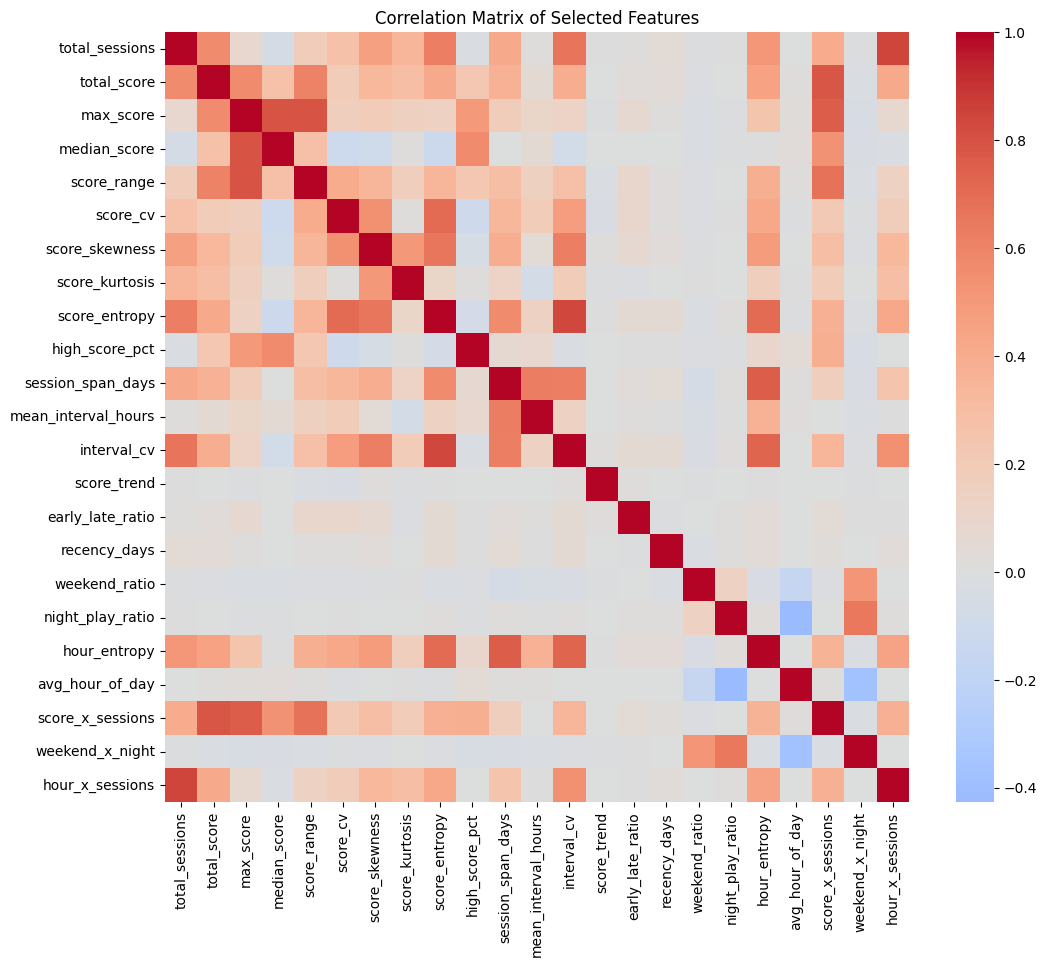

In [1051]:
# Step 2: Correlation Analysis
corr_matrix_train = X_train_step1.corr().abs()

# Find pairs of highly correlated features
high_corr_pairs = []
for i in range(len(corr_matrix_train.columns)):
    for j in range(i+1, len(corr_matrix_train.columns)):
        if corr_matrix_train.iloc[i, j] > 0.9:
            high_corr_pairs.append({
                'feature1': corr_matrix_train.columns[i],
                'feature2': corr_matrix_train.columns[j],
                'correlation': corr_matrix_train.iloc[i, j]
            })

print(f"  Found {len(high_corr_pairs)} highly correlated pairs (r > 0.9)")
# For highly correlated pairs, keep the one with higher importance from Random Forest
rf_importance = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_importance.fit(X_train_step1, y_train)
importance_dict = dict(zip(X_train_step1.columns, rf_importance.feature_importances_))

# Remove lower importance features in highly correlated pairs
features_to_remove = set()
for pair in high_corr_pairs:
    f1, f2 = pair['feature1'], pair['feature2']
    if f1 not in importance_dict or f2 not in importance_dict:
        continue
    # Remove the feature with lower importance
    if importance_dict[f1] < importance_dict[f2]:
        features_to_remove.add(f1)
    else:
        features_to_remove.add(f2)
    
    print(f"  - Removing '{f1 if importance_dict[f1] < importance_dict[f2] else f2}' "
          f"(corr={pair['correlation']:.3f} with '{f2 if importance_dict[f1] < importance_dict[f2] else f1}')")

X_train_final = X_train_step1.drop(columns=list(features_to_remove))
X_test_final = X_test_step1.drop(columns=list(features_to_remove))

print(f"  Removed {len(features_to_remove)} correlated features")
print(f"  Remaining: {X_train_final.shape[1]} features")

# Heatmap of remaining features correlation
plt.figure(figsize=(12, 10))
sns.heatmap(X_train_final.corr(), cmap='coolwarm', center=0, annot=False, fmt=".2f")
plt.title('Correlation Matrix of Selected Features')
plt.show()


## 7. Model Training 

In [1052]:
# Address class imbalance with SMOTEENN
smt = SMOTEENN(random_state=42, sampling_strategy=0.5) 
X_train_res, y_train_res = smt.fit_resample(X_train_final, y_train)

print("Churn distribution in training set after resampling:")
print(y_train_res.value_counts(normalize=True))

Churn distribution in training set after resampling:
churn
1.0    0.659321
0.0    0.340679
Name: proportion, dtype: float64


In [1032]:
# Cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Model evaluation storage
cv_results_all = {}
model_results = {}


### 7.1 Train Random Forest model

In [1053]:
# Custom class weights to emphasize minority class
class_weight_rf = {
    0: len(y_train_res) / (2 * (y_train_res == 0).sum()) * 2.0,  # 2x boost for minority
    1: len(y_train_res) / (2 * (y_train_res == 1).sum())
}

# Train random forest model with final features
rf_model = RandomForestClassifier(
    n_estimators=700,
    max_depth=40,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight=class_weight_rf,  # Custom weights
    random_state=42,
    n_jobs=-1,
    bootstrap=False,
    max_features='sqrt'
)

# Cross-validation
rf_cv_results = cross_validate(
    rf_model, 
    X_train_res, 
    y_train_res, 
    cv=cv_strategy,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

cv_results_all['Random Forest'] = rf_cv_results

# Train on full training set
rf_model.fit(X_train_res, y_train_res)

# Predict with threshold optimization
y_pred_proba_rf = rf_model.predict_proba(X_test_final)[:, 1]

# Find optimal threshold for minority class
thresholds = np.arange(0.3, 0.8, 0.05)
best_f1_minority = 0
best_threshold_rf = 0.5

for thresh in thresholds:
    y_pred_temp = (y_pred_proba_rf >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_temp)
    tn, fp, fn, tp = cm.ravel()
    
    minority_prec = tn / (tn + fn) if (tn + fn) > 0 else 0
    minority_rec = tn / (tn + fp) if (tn + fp) > 0 else 0
    minority_f1 = 2 * (minority_prec * minority_rec) / (minority_prec + minority_rec) if (minority_prec + minority_rec) > 0 else 0
    
    if minority_f1 > best_f1_minority:
        best_f1_minority = minority_f1
        best_threshold_rf = thresh

print(f"Optimal threshold for minority class: {best_threshold_rf:.2f}")

# Final predictions with optimal threshold
y_pred_rf = (y_pred_proba_rf >= best_threshold_rf).astype(int)

# Evaluation
print("\nTest Set Performance (Random Forest):")
print(classification_report(y_test, y_pred_rf))

# Calculate minority class metrics
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()

test_metrics_rf = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_rf),
    'Minority_Precision': tn / (tn + fn) if (tn + fn) > 0 else 0,
    'Minority_Recall': tn / (tn + fp) if (tn + fp) > 0 else 0,
    'Minority_F1': 2 * (tn / (tn + fn)) * (tn / (tn + fp)) / ((tn / (tn + fn)) + (tn / (tn + fp))) if (tn + fn) > 0 and (tn + fp) > 0 else 0
}

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
test_metrics_rf['PR-AUC'] = auc(recall_rf, precision_rf)

print("\nMetrics Summary:")
print(f"  Overall F1:       {test_metrics_rf['F1-Score']:.4f}")
print(f"  ROC-AUC:          {test_metrics_rf['ROC-AUC']:.4f}")
print(f"  PR-AUC:           {test_metrics_rf['PR-AUC']:.4f}")
print(f"  Minority F1:      {test_metrics_rf['Minority_F1']:.4f}")

model_results['Random Forest'] = {
    'model': rf_model,
    'metrics': test_metrics_rf,
    'y_pred': y_pred_rf,
    'y_prob': y_pred_proba_rf,
    'threshold': best_threshold_rf
}


Optimal threshold for minority class: 0.40

Test Set Performance (Random Forest):
              precision    recall  f1-score   support

         0.0       0.38      0.43      0.40       386
         1.0       0.95      0.94      0.95      4806

    accuracy                           0.90      5192
   macro avg       0.67      0.69      0.68      5192
weighted avg       0.91      0.90      0.91      5192


Metrics Summary:
  Overall F1:       0.9481
  ROC-AUC:          0.7798
  PR-AUC:           0.9684
  Minority F1:      0.4024


### 7.2 Train XGBoost

In [1079]:
# Calculate scale_pos_weight 
scale_pos_weight = n_majority / n_minority

# Train XGBoost model with final features
xgb_model = XGBClassifier(
    n_estimators=538,
    max_depth=11,
    learning_rate=0.22049478030358585,
    subsample=0.7541501002496411,
    colsample_bytree=0.6439668655986582,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    n_jobs=-1
)

# Cross-validation
xgb_cv_results = cross_validate(
    xgb_model, 
    X_train_res, 
    y_train_res, 
    cv=cv_strategy,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

cv_results_all['XGBoost'] = xgb_cv_results

# Train on full  training set
xgb_model.fit(X_train_res, y_train_res)

# Predict on original test set
y_prob_xgb = xgb_model.predict_proba(X_test_final)[:, 1]

# Threshold optimization
thresholds = np.arange(0.01, 0.8, 0.01)
best_f1_minority = 0
best_threshold_xgb = 0.5

for thresh in thresholds:
    y_pred_temp = (y_prob_xgb >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_temp)
    tn, fp, fn, tp = cm.ravel()
    
    minority_prec = tn / (tn + fn) if (tn + fn) > 0 else 0
    minority_rec = tn / (tn + fp) if (tn + fp) > 0 else 0
    minority_f1 = 2 * (minority_prec * minority_rec) / (minority_prec + minority_rec) if (minority_prec + minority_rec) > 0 else 0
    
    if minority_f1 > best_f1_minority:
        best_f1_minority = minority_f1
        best_threshold_xgb = thresh

print(f"Optimal threshold for minority class: {best_threshold_xgb:.2f}")

# Final predictions
y_pred_xgb = (y_prob_xgb >= best_threshold_xgb).astype(int)

# Evaluation
print("\nTest Set Performance (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm_xgb.ravel()

test_metrics_xgb = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1-Score': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_prob_xgb),
    'Minority_Precision': tn / (tn + fn) if (tn + fn) > 0 else 0,
    'Minority_Recall': tn / (tn + fp) if (tn + fp) > 0 else 0,
    'Minority_F1': 2 * (tn / (tn + fn)) * (tn / (tn + fp)) / ((tn / (tn + fn)) + (tn / (tn + fp)))
        if (tn + fn) > 0 and (tn + fp) > 0 else 0
}

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
test_metrics_xgb['PR-AUC'] = auc(recall_xgb, precision_xgb)

print("\nMetrics Summary:")
print(f"  Overall F1:       {test_metrics_xgb['F1-Score']:.4f}")
print(f"  ROC-AUC:          {test_metrics_xgb['ROC-AUC']:.4f}")
print(f"  PR-AUC:           {test_metrics_xgb['PR-AUC']:.4f}")
print(f"  Minority F1:      {test_metrics_xgb['Minority_F1']:.4f}")

model_results['XGBoost'] = {
    'model': xgb_model,
    'metrics': test_metrics_xgb,
    'y_pred': y_pred_xgb,
    'y_prob': y_prob_xgb,
    'threshold': best_threshold_xgb
}


Optimal threshold for minority class: 0.08

Test Set Performance (XGBoost):
              precision    recall  f1-score   support

         0.0       0.45      0.37      0.40       386
         1.0       0.95      0.96      0.96      4806

    accuracy                           0.92      5192
   macro avg       0.70      0.67      0.68      5192
weighted avg       0.91      0.92      0.92      5192


Metrics Summary:
  Overall F1:       0.9568
  ROC-AUC:          0.7708
  PR-AUC:           0.9690
  Minority F1:      0.4046


### 7.3 Train CatBoost

In [1055]:
# Create Pool objects
train_pool = Pool(X_train_res, y_train_res)
test_pool = Pool(X_test_final, y_test)

# Initialize CatBoost model
cat_model = CatBoostClassifier(
    iterations=987,
    learning_rate=0.08949189491904928,
    l2_leaf_reg=1.729031477245327,
    border_count=207,
    depth=9,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=0,
    task_type='CPU'
)

# Train
cat_model.fit(train_pool, eval_set=test_pool, verbose=100)

# Predict on original test set
y_prob_cat = cat_model.predict_proba(test_pool)[:, 1]

# Threshold optimization
thresholds = np.arange(0.01, 0.8, 0.01)
best_f1_minority = 0
best_threshold_cat = 0.5

for thresh in thresholds:
    y_pred_temp = (y_prob_cat >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_temp)
    tn, fp, fn, tp = cm.ravel()
    
    minority_prec = tn / (tn + fn) if (tn + fn) > 0 else 0
    minority_rec = tn / (tn + fp) if (tn + fp) > 0 else 0
    minority_f1 = 2 * (minority_prec * minority_rec) / (minority_prec + minority_rec) if (minority_prec + minority_rec) > 0 else 0
    
    if minority_f1 > best_f1_minority:
        best_f1_minority = minority_f1
        best_threshold_cat = thresh

print(f"Optimal threshold for minority class: {best_threshold_cat:.2f}")

# Final predictions
y_pred_cat = (y_prob_cat >= best_threshold_cat).astype(int)

# Evaluation
print("\nTest Set Performance (CatBoost):")
print(classification_report(y_test, y_pred_cat, target_names=['Non-churner', 'Churner']))

cm_cat = confusion_matrix(y_test, y_pred_cat)
tn, fp, fn, tp = cm_cat.ravel()

test_metrics_cat = {
    'Accuracy': accuracy_score(y_test, y_pred_cat),
    'Precision': precision_score(y_test, y_pred_cat),
    'Recall': recall_score(y_test, y_pred_cat),
    'F1-Score': f1_score(y_test, y_pred_cat),
    'ROC-AUC': roc_auc_score(y_test, y_prob_cat),
    'Minority_Precision': tn / (tn + fn) if (tn + fn) > 0 else 0,
    'Minority_Recall': tn / (tn + fp) if (tn + fp) > 0 else 0,
    'Minority_F1': (
        2 * (tn / (tn + fn)) * (tn / (tn + fp)) /
        ((tn / (tn + fn)) + (tn / (tn + fp)))
        if (tn + fn) > 0 and (tn + fp) > 0 else 0
    )
}

precision_cat, recall_cat, _ = precision_recall_curve(y_test, y_prob_cat)
test_metrics_cat['PR-AUC'] = auc(recall_cat, precision_cat)

print("\nMetrics Summary:")
print(f"  Overall F1:       {test_metrics_cat['F1-Score']:.4f}")
print(f"  ROC-AUC:          {test_metrics_cat['ROC-AUC']:.4f}")
print(f"  PR-AUC:           {test_metrics_cat['PR-AUC']:.4f}")
print(f"  Minority F1:      {test_metrics_cat['Minority_F1']:.4f}")

model_results['CatBoost'] = {
    'model': cat_model,
    'metrics': test_metrics_cat,
    'y_pred': y_pred_cat,
    'y_prob': y_prob_cat,
    'threshold': best_threshold_cat
}


0:	test: 0.7746739	best: 0.7746739 (0)	total: 96.4ms	remaining: 1m 35s
100:	test: 0.7940105	best: 0.7976558 (63)	total: 4.99s	remaining: 43.8s
200:	test: 0.7826360	best: 0.7976558 (63)	total: 9.98s	remaining: 39s
300:	test: 0.7803081	best: 0.7976558 (63)	total: 14.8s	remaining: 33.7s
400:	test: 0.7757739	best: 0.7976558 (63)	total: 20s	remaining: 29.2s
500:	test: 0.7721574	best: 0.7976558 (63)	total: 24.9s	remaining: 24.1s
600:	test: 0.7718701	best: 0.7976558 (63)	total: 29.7s	remaining: 19.1s
700:	test: 0.7705623	best: 0.7976558 (63)	total: 34.5s	remaining: 14.1s
800:	test: 0.7694255	best: 0.7976558 (63)	total: 39.4s	remaining: 9.14s
900:	test: 0.7676870	best: 0.7976558 (63)	total: 44.4s	remaining: 4.24s
986:	test: 0.7678795	best: 0.7976558 (63)	total: 48.4s	remaining: 0us

bestTest = 0.79765578
bestIteration = 63

Shrink model to first 64 iterations.
Optimal threshold for minority class: 0.18

Test Set Performance (CatBoost):
              precision    recall  f1-score   support

 No

## 8. Test OP/CP combination

In [ ]:
# Test different OP/CP combinations
op_cp_combinations = [(3, 7), (5, 10), (7, 7), (7, 14)]

results_summary = []

for OP_days, CP_days in op_cp_combinations:
    
    # 1. Create churn labels
    windows, counts = create_churn_labels(df, OP_days, CP_days)
    
    # 2. Create features
    features = features_engineer(df, windows, OP_days)
    
    # 3. Merge features with labels
    dataset = counts[['device', 'churn']].merge(features, on='device', how='left')
    dataset = dataset.dropna(subset=['churn'])
    
    churn_rate = dataset['churn'].mean()
    n_samples = len(dataset)
    
    # 4. Prepare X and y
    X = dataset.drop(columns=['device', 'churn'])
    y = dataset['churn']
    
    # 5. Split data
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 6. Apply SMOTEENN only to training set
    smt = SMOTEENN(random_state=42, sampling_strategy=0.5)
    X_train_bal, y_train_bal = smt.fit_resample(X_train_temp, y_train_temp)
    
    # 7. Train three models
    models = {
            'Random Forest': RandomForestClassifier(
            n_estimators=700,
            max_depth=40,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight=class_weight_rf,
            random_state=42,
            n_jobs=-1,
            bootstrap=False,
            max_features='sqrt'
        ),
        'XGBoost': XGBClassifier(
            n_estimators=538,
            max_depth=11,
            learning_rate=0.22049478030358585,
            subsample=0.7541501002496411,
            colsample_bytree=0.6439668655986582,
            random_state=42,
            scale_pos_weight=scale_pos_weight,
            eval_metric='logloss',
            n_jobs=-1
        ),
        'CatBoost': CatBoostClassifier(
            iterations=987,
            learning_rate=0.08949189491904928,
            l2_leaf_reg = 1.729031477245327,
            border_count = 207,
            depth=9,
            loss_function='Logloss',
            eval_metric='AUC',
            random_seed=42,
            verbose=0,
            task_type='CPU'
        )
    }
    
    for model_name, model in models.items():        
        # Train model on balanced training set
        model.fit(X_train_bal, y_train_bal)

        # Predict probabilities
        y_pred_proba = model.predict_proba(X_test_temp)[:, 1]

        # FIND BEST THRESHOLD FOR MINORITY CLASS
        best_f1_min = 0
        best_thresh = 0.5

        for th in thresholds:
            y_temp = (y_pred_proba >= th).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_test_temp, y_temp).ravel()

            prec_min = tn / (tn + fn) if (tn + fn) else 0
            rec_min = tn / (tn + fp) if (tn + fp) else 0
            f1_min = 2 * prec_min * rec_min / (prec_min + rec_min) if (prec_min + rec_min) else 0

            if f1_min > best_f1_min:
                best_f1_min = f1_min
                best_thresh = th

        # Final predictions with threshold
        y_pred = (y_pred_proba >= best_thresh).astype(int)

        # Calculate metrics
        roc_auc = roc_auc_score(y_test_temp, y_pred_proba)
        precision, recall, _ = precision_recall_curve(y_test_temp, y_pred_proba)
        pr_auc = auc(recall, precision)
        prec = precision_score(y_test_temp, y_pred)
        rec = recall_score(y_test_temp, y_pred)
        f1 = f1_score(y_test_temp, y_pred)

        tn, fp, fn, tp = confusion_matrix(y_test_temp, y_pred).ravel()
        minority_f1 = best_f1_min

        results_summary.append({
            'OP': OP_days,
            'CP': CP_days,
            'Churn_Rate': churn_rate,
            'Model': model_name,
            'ROC-AUC': roc_auc,
            'PR-AUC': pr_auc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1,
            'Minority_F1': minority_f1,
            'Threshold': best_thresh
        })


# Create summary dataframe
results_df = pd.DataFrame(results_summary)

print("SUMMARY OF ALL OP/CP COMBINATIONS")
print(results_df.to_string(index=False))

# Find best combination
best_combo = results_df.loc[results_df['ROC-AUC'].idxmax()]
print(f"BEST COMBINATION (by ROC-AUC)")
print(f"OP: {best_combo['OP']} days")
print(f"CP: {best_combo['CP']} days")
print(f"Model: {best_combo['Model']}")
print(f"ROC-AUC: {best_combo['ROC-AUC']:.4f}")
print(f"PR-AUC: {best_combo['PR-AUC']:.4f}")
print(f"F1-Score: {best_combo['F1']:.4f}")
print(f"Churn Rate: {best_combo['Churn_Rate']:.2%}")


C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_7092\965139948.py:101: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend = df_OP.groupby('device').apply(calc_score_trend).rename('score_trend')
C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_7092\965139948.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  el_ratio = df_OP.groupby('device').apply(calc_early_late_ratio).rename('early_late_ratio')
C:\Users\Anh Thu\AppD

 Created 33 features


C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_7092\965139948.py:101: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend = df_OP.groupby('device').apply(calc_score_trend).rename('score_trend')
C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_7092\965139948.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  el_ratio = df_OP.groupby('device').apply(calc_early_late_ratio).rename('early_late_ratio')
C:\Users\Anh Thu\AppD

 Created 33 features


C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_7092\965139948.py:101: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend = df_OP.groupby('device').apply(calc_score_trend).rename('score_trend')
C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_7092\965139948.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  el_ratio = df_OP.groupby('device').apply(calc_early_late_ratio).rename('early_late_ratio')
C:\Users\Anh Thu\AppD

 Created 33 features


C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_7092\965139948.py:101: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend = df_OP.groupby('device').apply(calc_score_trend).rename('score_trend')
C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_7092\965139948.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  el_ratio = df_OP.groupby('device').apply(calc_early_late_ratio).rename('early_late_ratio')
C:\Users\Anh Thu\AppD

 Created 33 features
SUMMARY OF ALL OP/CP COMBINATIONS
 OP  CP  Churn_Rate         Model  ROC-AUC   PR-AUC  Precision   Recall       F1  Minority_F1  Threshold
  3   7    0.911080 Random Forest 0.775167 0.959717   0.944682 0.935095 0.939864     0.417695       0.42
  3   7    0.911080       XGBoost 0.765729 0.960784   0.946905 0.931290 0.939032     0.429142       0.64
  3   7    0.911080      CatBoost 0.764662 0.960134   0.943167 0.936786 0.939966     0.407950       0.43
  5  10    0.925720 Random Forest 0.786709 0.971460   0.950010 0.964836 0.957366     0.407461       0.23
  5  10    0.925720       XGBoost 0.777166 0.970937   0.951947 0.956305 0.954121     0.410667       0.22
  5  10    0.925720      CatBoost 0.771928 0.969094   0.953076 0.950895 0.951984     0.411239       0.27
  7   7    0.950493 Random Forest 0.783844 0.979351   0.970820 0.950557 0.960582     0.376013       0.41
  7   7    0.950493       XGBoost 0.770793 0.980284   0.969579 0.955826 0.962653     0.373288       0.38


C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_7092\2144052380.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_data['OP_CP'] = model_data['OP'].astype(str) + '/' + model_data['CP'].astype(str)
C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_7092\2144052380.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_data['OP_CP'] = model_data['OP'].astype(str) + '/' + model_data['CP'].astype(str)
C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_7092\2144052380.py:10: SettingWithCopyWarning: 
A value is t

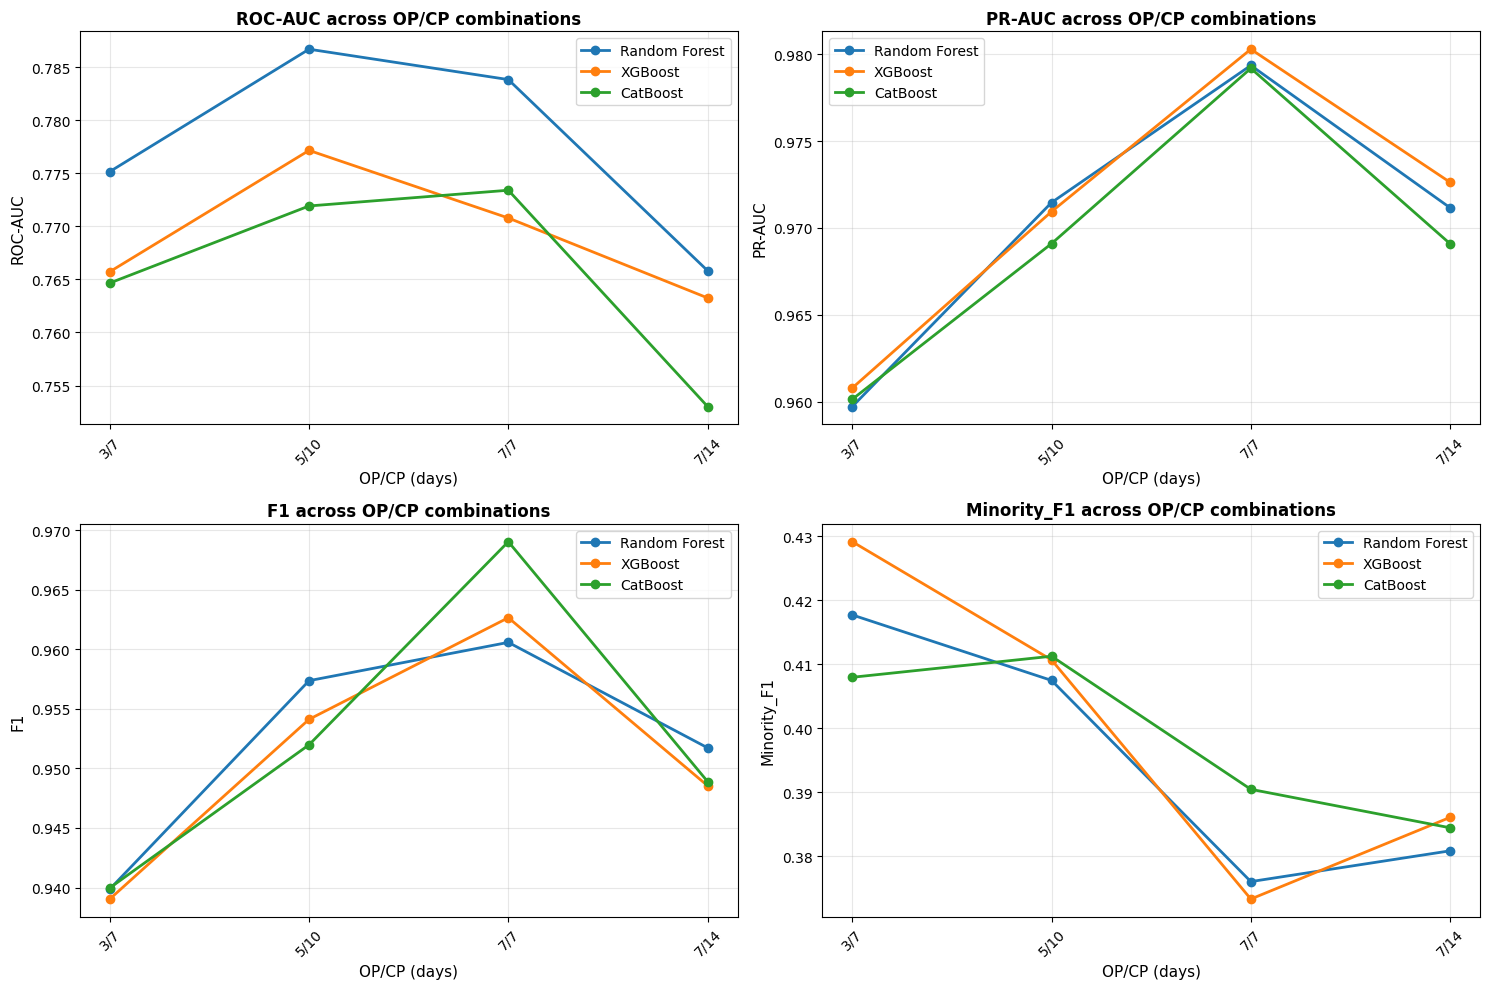

In [1057]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metrics = ['ROC-AUC', 'PR-AUC', 'F1', 'Minority_F1']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    for model in results_df['Model'].unique():
        model_data = results_df[results_df['Model'] == model]
        model_data['OP_CP'] = model_data['OP'].astype(str) + '/' + model_data['CP'].astype(str)
        ax.plot(model_data['OP_CP'], model_data[metric], marker='o', linewidth=2, label=model)
    
    ax.set_xlabel('OP/CP (days)', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'{metric} across OP/CP combinations', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 9. Hyperparameter Tuning

In [1023]:
# Hyperparameter tuning for Random Forest using Optuna
# Define PR-AUC scorer
def minority_f1_scorer(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    minority_prec = tn / (tn + fn) if (tn + fn) > 0 else 0
    minority_rec = tn / (tn + fp) if (tn + fp) > 0 else 0
    return 2 * minority_prec * minority_rec / (minority_prec + minority_rec) if (minority_prec + minority_rec) > 0 else 0

minority_scorer = make_scorer(minority_f1_scorer)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Objective function for Optuna
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 1000, step=50)
    max_depth = trial.suggest_int('max_depth', 5, 50, step=5)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        class_weight=class_weight_rf, 
        n_jobs=-1,
        random_state=42
    )
    
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv_strategy,
        scoring=pr_auc_scorer,
        n_jobs=-1
    )
    
    return scores.mean()

# Run Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best hyperparameters:")
print(study.best_params)
print(f"Best CV PR-AUC: {study.best_value:.4f}")

# Train final tuned model
best_params = study.best_params

rf_model_opt = RandomForestClassifier(
    **best_params,
    class_weight=class_weight_rf,
    n_jobs=-1,
    random_state=42
)

rf_model_opt.fit(X_train, y_train)

# Predict and threshold search
y_pred_proba_rf = rf_model_opt.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.3, 0.8, 0.05)
best_f1_minority = 0
best_threshold_rf = 0.5

for thresh in thresholds:
    y_pred_temp = (y_pred_proba_rf >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()

    minority_prec = tn / (tn + fn) if (tn + fn) > 0 else 0
    minority_rec = tn / (tn + fp) if (tn + fp) > 0 else 0
    minority_f1 = (
        2 * minority_prec * minority_rec / (minority_prec + minority_rec)
        if (minority_prec + minority_rec) > 0 else 0
    )

    if minority_f1 > best_f1_minority:
        best_f1_minority = minority_f1
        best_threshold_rf = thresh

print(f"Optimal threshold for minority class: {best_threshold_rf:.2f}")

# Final predictions
y_pred_rf = (y_pred_proba_rf >= best_threshold_rf).astype(int)

# Evaluation metrics
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()

test_metrics_rf = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_rf),
    'Minority_Precision': tn / (tn + fn) if (tn + fn) > 0 else 0,
    'Minority_Recall': tn / (tn + fp) if (tn + fp) > 0 else 0,
    'Minority_F1': 2 * (tn / (tn + fn)) * (tn / (tn + fp)) / ((tn / (tn + fn)) + (tn / (tn + fp))) if (tn + fn) > 0 and (tn + fp) > 0 else 0
}

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
test_metrics_rf['PR-AUC'] = auc(recall_rf, precision_rf)

print("\nMetrics Summary:")
print(f"  Overall F1:       {test_metrics_rf['F1-Score']:.4f}")
print(f"  ROC-AUC:          {test_metrics_rf['ROC-AUC']:.4f}")
print(f"  PR-AUC:           {test_metrics_rf['PR-AUC']:.4f}")
print(f"  Minority F1:      {test_metrics_rf['Minority_F1']:.4f}")

model_results['Random Forest'] = {
    'model': rf_model_opt,
    'metrics': test_metrics_rf,
    'y_pred': y_pred_rf,
    'y_prob': y_pred_proba_rf,
    'threshold': best_threshold_rf
}


[I 2025-12-04 11:41:47,412] A new study created in memory with name: no-name-29b8d63f-416f-43a7-948b-4d3f75df784a
[I 2025-12-04 11:43:36,070] Trial 0 finished with value: 0.9154642190889787 and parameters: {'n_estimators': 941, 'max_depth': 43, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.9154642190889787.
[I 2025-12-04 11:45:08,357] Trial 1 finished with value: 0.9166030603025026 and parameters: {'n_estimators': 839, 'max_depth': 53, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 0.9166030603025026.
[I 2025-12-04 11:47:09,607] Trial 2 finished with value: 0.9204264594041863 and parameters: {'n_estimators': 898, 'max_depth': 49, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': False}. Best is trial 2 with value: 0.9204264594041863.
[I 2025-12-04 11:47:42,015] Trial 3 finished with value: 0.8888340543213932

Best params: {'n_estimators': 521, 'max_depth': 40, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False}
Best minority F1: 0.9276259911418633

Optimal threshold on test set: 0.35
FINAL TEST METRICS
Accuracy: 0.9079
Precision: 0.9523
Recall: 0.9480
F1: 0.9502
ROC-AUC: 0.7786
Minority Precision: 0.3873
Minority Recall: 0.4093
Minority F1: 0.3980
PR-AUC: 0.9759


In [1074]:
# Define objective function for Optuna
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'scale_pos_weight': scale_pos_weight,
        'eval_metric': 'logloss',
        'use_label_encoder': False
    }
    
    model = XGBClassifier(**params)
    
    # Use StratifiedKFold to maintain class distribution
    cv_scores = cross_val_score(
        model, X_train_res, y_train_res,
        cv=cv_strategy,
        scoring='f1', 
        n_jobs=-1
    )
    
    return cv_scores.mean()

# Run Optuna study
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50)

print("Best trial:")
print(study_xgb.best_trial.params)

# Train final XGBoost with best hyperparameters
best_params_xgb = study_xgb.best_trial.params
best_params_xgb['scale_pos_weight'] = scale_pos_weight
best_params_xgb['random_state'] = 42
best_params_xgb['n_jobs'] = -1
best_params_xgb['eval_metric'] = 'logloss'
best_params_xgb['use_label_encoder'] = False

xgb_model = XGBClassifier(**best_params_xgb)
xgb_model.fit(X_train_res, y_train_res)

# Threshold optimization (post-training)
y_prob_xgb = xgb_model.predict_proba(X_test_final)[:, 1]

best_f1_minority = 0
best_threshold_xgb = 0.5

for thresh in thresholds:
    y_pred_temp = (y_prob_xgb >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_temp)
    tn, fp, fn, tp = cm.ravel()
    
    minority_prec = tn / (tn + fn) if (tn + fn) > 0 else 0
    minority_rec = tn / (tn + fp) if (tn + fp) > 0 else 0
    minority_f1 = 2 * (minority_prec * minority_rec) / (minority_prec + minority_rec) if (minority_prec + minority_rec) > 0 else 0
    
    if minority_f1 > best_f1_minority:
        best_f1_minority = minority_f1
        best_threshold_xgb = thresh

print(f"Optimal threshold for minority class: {best_threshold_xgb:.2f}")

# Final predictions
y_pred_xgb = (y_prob_xgb >= best_threshold_xgb).astype(int)

# Evaluation metrics (reuse your previous code)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm_xgb.ravel()

test_metrics_xgb = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1-Score': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_prob_xgb),
    'Minority_Precision': tn / (tn + fn) if (tn + fn) > 0 else 0,
    'Minority_Recall': tn / (tn + fp) if (tn + fp) > 0 else 0,
    'Minority_F1': 2 * (tn / (tn + fn)) * (tn / (tn + fp)) / ((tn / (tn + fn)) + (tn / (tn + fp))) if (tn + fn) > 0 and (tn + fp) > 0 else 0
}

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
test_metrics_xgb['PR-AUC'] = auc(recall_xgb, precision_xgb)

print("\nMetrics Summary:")
print(f"  Overall F1:       {test_metrics_xgb['F1-Score']:.4f}")
print(f"  ROC-AUC:          {test_metrics_xgb['ROC-AUC']:.4f}")
print(f"  PR-AUC:           {test_metrics_xgb['PR-AUC']:.4f}")
print(f"  Minority F1:      {test_metrics_xgb['Minority_F1']:.4f}")

model_results['XGBoost'] = {
    'model': xgb_model,
    'metrics': test_metrics_xgb,
    'y_pred': y_pred_xgb,
    'y_prob': y_prob_xgb,
    'threshold': best_threshold_xgb
}


[I 2025-12-04 15:15:49,302] A new study created in memory with name: no-name-41e93f1c-51f8-4540-a847-82a4ca0e8163
[I 2025-12-04 15:15:56,584] Trial 0 finished with value: 0.9751726551477677 and parameters: {'n_estimators': 367, 'max_depth': 7, 'learning_rate': 0.2303919091623515, 'subsample': 0.9387262415338385, 'colsample_bytree': 0.7728248194762618}. Best is trial 0 with value: 0.9751726551477677.
[I 2025-12-04 15:16:03,599] Trial 1 finished with value: 0.9721806684932549 and parameters: {'n_estimators': 763, 'max_depth': 4, 'learning_rate': 0.11388300547421443, 'subsample': 0.9366383305445285, 'colsample_bytree': 0.9902557497684359}. Best is trial 0 with value: 0.9751726551477677.
[I 2025-12-04 15:16:13,055] Trial 2 finished with value: 0.9748246215508731 and parameters: {'n_estimators': 480, 'max_depth': 12, 'learning_rate': 0.06663231001274232, 'subsample': 0.9426551616064434, 'colsample_bytree': 0.6185262129049508}. Best is trial 0 with value: 0.9751726551477677.
[I 2025-12-04 15

Best trial:
{'n_estimators': 538, 'max_depth': 11, 'learning_rate': 0.22049478030358585, 'subsample': 0.7541501002496411, 'colsample_bytree': 0.6439668655986582}
Optimal threshold for minority class: 0.08

Metrics Summary:
  Overall F1:       0.9568
  ROC-AUC:          0.7708
  PR-AUC:           0.9690
  Minority F1:      0.4046


In [ ]:
# Objective function for CatBoost
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_seed': 42,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'CPU',
        'verbose': 0
    }
    
    model = CatBoostClassifier(**params)
    
    # Use StratifiedKFold for minority class balance
    cv_scores = cross_val_score(
        model,
        X_train_res,
        y_train_res,
        cv=cv_strategy,
        scoring='f1',  # Or custom minority F1 scorer
        n_jobs=-1
    )
    
    return cv_scores.mean()

# Run Optuna study
study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=50)

print("Best CatBoost trial:")
print(study_cat.best_trial.params)

# Train final CatBoost with best hyperparameters
best_params_cat = study_cat.best_trial.params
best_params_cat.update({
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': 42,
    'task_type': 'CPU',
    'verbose': 0
})

train_pool = Pool(X_train_res, y_train_res)
test_pool = Pool(X_test_final, y_test)

cat_model = CatBoostClassifier(**best_params_cat)
cat_model.fit(train_pool, eval_set=test_pool, verbose=100)

# Threshold optimization
y_prob_cat = cat_model.predict_proba(test_pool)[:, 1]

best_f1_minority = 0
best_threshold_cat = 0.5

for thresh in thresholds:
    y_pred_temp = (y_prob_cat >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_temp)
    tn, fp, fn, tp = cm.ravel()
    
    minority_prec = tn / (tn + fn) if (tn + fn) > 0 else 0
    minority_rec = tn / (tn + fp) if (tn + fp) > 0 else 0
    minority_f1 = 2 * (minority_prec * minority_rec) / (minority_prec + minority_rec) if (minority_prec + minority_rec) > 0 else 0
    
    if minority_f1 > best_f1_minority:
        best_f1_minority = minority_f1
        best_threshold_cat = thresh

print(f"Optimal threshold for minority class: {best_threshold_cat:.2f}")

# Final predictions
y_pred_cat = (y_prob_cat >= best_threshold_cat).astype(int)

# Evaluation metrics
cm_cat = confusion_matrix(y_test, y_pred_cat)
tn, fp, fn, tp = cm_cat.ravel()

test_metrics_cat = {
    'Accuracy': accuracy_score(y_test, y_pred_cat),
    'Precision': precision_score(y_test, y_pred_cat),
    'Recall': recall_score(y_test, y_pred_cat),
    'F1-Score': f1_score(y_test, y_pred_cat),
    'ROC-AUC': roc_auc_score(y_test, y_prob_cat),
    'Minority_Precision': tn / (tn + fn) if (tn + fn) > 0 else 0,
    'Minority_Recall': tn / (tn + fp) if (tn + fp) > 0 else 0,
    'Minority_F1': 2 * (tn / (tn + fn)) * (tn / (tn + fp)) / ((tn / (tn + fn)) + (tn / (tn + fp))) if (tn + fn) > 0 and (tn + fp) > 0 else 0
}

precision_cat, recall_cat, _ = precision_recall_curve(y_test, y_prob_cat)
test_metrics_cat['PR-AUC'] = auc(recall_cat, precision_cat)

print("\nMetrics Summary:")
print(f"  Overall F1:       {test_metrics_cat['F1-Score']:.4f}")
print(f"  ROC-AUC:          {test_metrics_cat['ROC-AUC']:.4f}")
print(f"  PR-AUC:           {test_metrics_cat['PR-AUC']:.4f}")
print(f"  Minority F1:      {test_metrics_cat['Minority_F1']:.4f}")

model_results['CatBoost'] = {
    'model': cat_model,
    'metrics': test_metrics_cat,
    'y_pred': y_pred_cat,
    'y_prob': y_prob_cat,
    'threshold': best_threshold_cat
}

[I 2025-12-04 15:35:43,269] A new study created in memory with name: no-name-69f68d0d-7a01-408b-935f-9d3e281d450d
[I 2025-12-04 15:36:03,485] Trial 0 finished with value: 0.9695105128630086 and parameters: {'iterations': 397, 'depth': 7, 'learning_rate': 0.081854062456314, 'l2_leaf_reg': 7.0920791278635145, 'border_count': 206}. Best is trial 0 with value: 0.9695105128630086.
[I 2025-12-04 15:36:38,763] Trial 1 finished with value: 0.9726015901072074 and parameters: {'iterations': 657, 'depth': 9, 'learning_rate': 0.09093200887616795, 'l2_leaf_reg': 7.655136752789211, 'border_count': 64}. Best is trial 1 with value: 0.9726015901072074.
[I 2025-12-04 15:36:48,403] Trial 2 finished with value: 0.9557465582578946 and parameters: {'iterations': 254, 'depth': 7, 'learning_rate': 0.021956002309366247, 'l2_leaf_reg': 8.602214791213072, 'border_count': 151}. Best is trial 1 with value: 0.9726015901072074.
[I 2025-12-04 15:36:59,176] Trial 3 finished with value: 0.9622383428215322 and parameter

## 10. Model Performance Comparison

In [617]:
# Create summary dataframe for tuning results
tuned_rf_metrics = tuned_rf_metrics
tuned_xgb_metrics = tuned_xgb_metrics
tuned_cat_metrics = cat_tuned


summary_df = pd.DataFrame([
tuned_rf_metrics,
tuned_xgb_metrics,
tuned_cat_metrics
], index=["Random Forest", "XGBoost", "CatBoost"])


print("SUMMARY OF TUNED MODEL PERFORMANCE:")
print(summary_df)

SUMMARY OF TUNED MODEL PERFORMANCE:
               Accuracy  Precision    Recall  F1-Score   ROC-AUC    PR-AUC
Random Forest  0.947238   0.951927  0.969828  0.960794  0.978571  0.986057
XGBoost        0.955090   0.953933  0.979955  0.966769  0.977176  0.981882
CatBoost       0.955641   0.955435  0.979128  0.967136  0.976719  0.981693


In [618]:
best_models = summary_df.idxmax()
print("\nBEST MODEL FOR EACH METRIC:")
print(best_models)


BEST MODEL FOR EACH METRIC:
Accuracy          CatBoost
Precision         CatBoost
Recall             XGBoost
F1-Score          CatBoost
ROC-AUC      Random Forest
PR-AUC       Random Forest
dtype: object


In [619]:
# Extract CV scores from tuning objects
cv_scores = {
"Random Forest": rf_search.best_score_,
"XGBoost": xgb_search.best_score_,
"CatBoost": cat_search.best_score_
}


# Extract Test ROC-AUC from summary table
test_scores = summary_df["ROC-AUC"].to_dict()


cv_test_comparison = pd.DataFrame({
"CV ROC-AUC": cv_scores,
"Test ROC-AUC": test_scores
})


cv_test_comparison["Gap (CV - Test)"] = cv_test_comparison["CV ROC-AUC"] - cv_test_comparison["Test ROC-AUC"]


print("\nCROSS-VALIDATION VS TEST SET COMPARISON:")
print(cv_test_comparison)


CROSS-VALIDATION VS TEST SET COMPARISON:
               CV ROC-AUC  Test ROC-AUC  Gap (CV - Test)
Random Forest    0.972196      0.978571        -0.006374
XGBoost          0.972684      0.977176        -0.004491
CatBoost         0.973547      0.976719        -0.003172


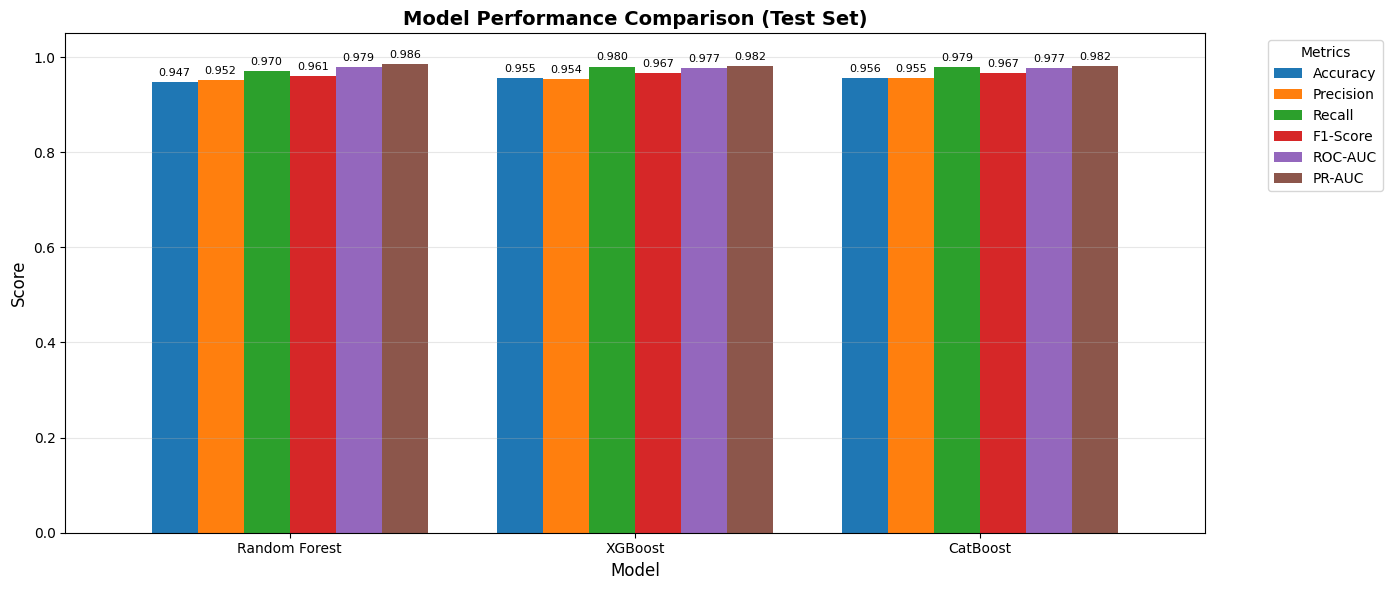

In [620]:
# Test Set Metrics Comparison
fig, ax = plt.subplots(figsize=(14, 6))
summary_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Model Performance Comparison (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticklabels(summary_df.index, rotation=0)
ax.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.05])
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

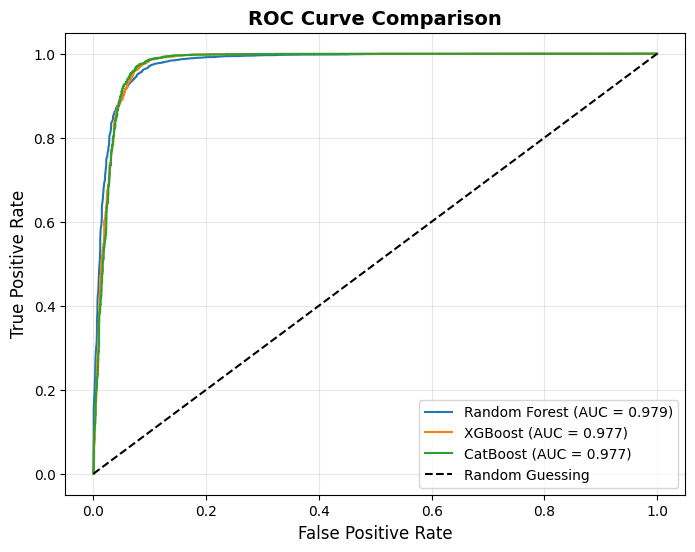

In [621]:
# 2. ROC Curves Comparison

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = {:.3f})'.format(tuned_rf_metrics['ROC-AUC']))
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC = {:.3f})'.format(tuned_xgb_metrics['ROC-AUC']))
plt.plot(fpr_cat, tpr_cat, label='CatBoost (AUC = {:.3f})'.format(tuned_cat_metrics['ROC-AUC']))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

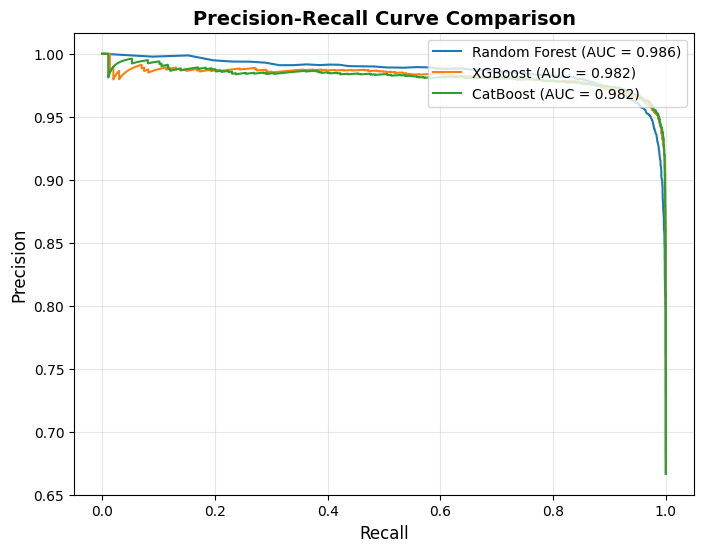

In [622]:
# 3. Precision-Recall Curves Comparison
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
precision_cat, recall_cat, _ = precision_recall_curve(y_test, y_prob_cat)
plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, label='Random Forest (AUC = {:.3f})'.format(tuned_rf_metrics['PR-AUC']))
plt.plot(recall_xgb, precision_xgb, label='XGBoost (AUC = {:.3f})'.format(tuned_xgb_metrics['PR-AUC']))
plt.plot(recall_cat, precision_cat, label='CatBoost (AUC = {:.3f})'.format(tuned_cat_metrics['PR-AUC']))
plt.title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

## 11. Feature Importance Analysis


=== SHAP Analysis for Tuned CatBoost ===


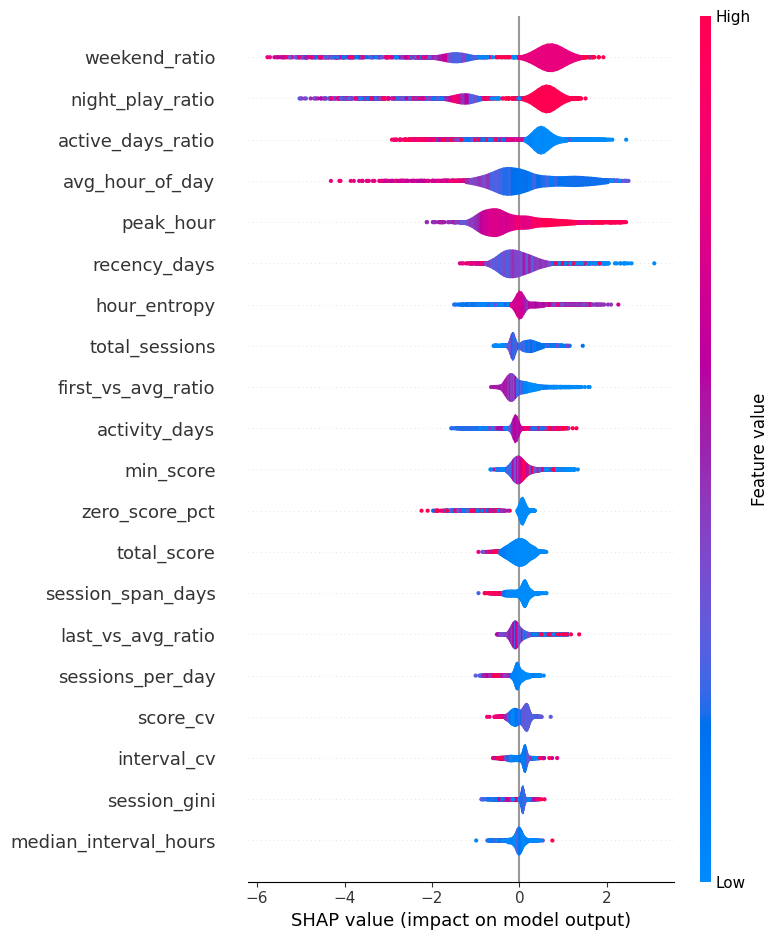

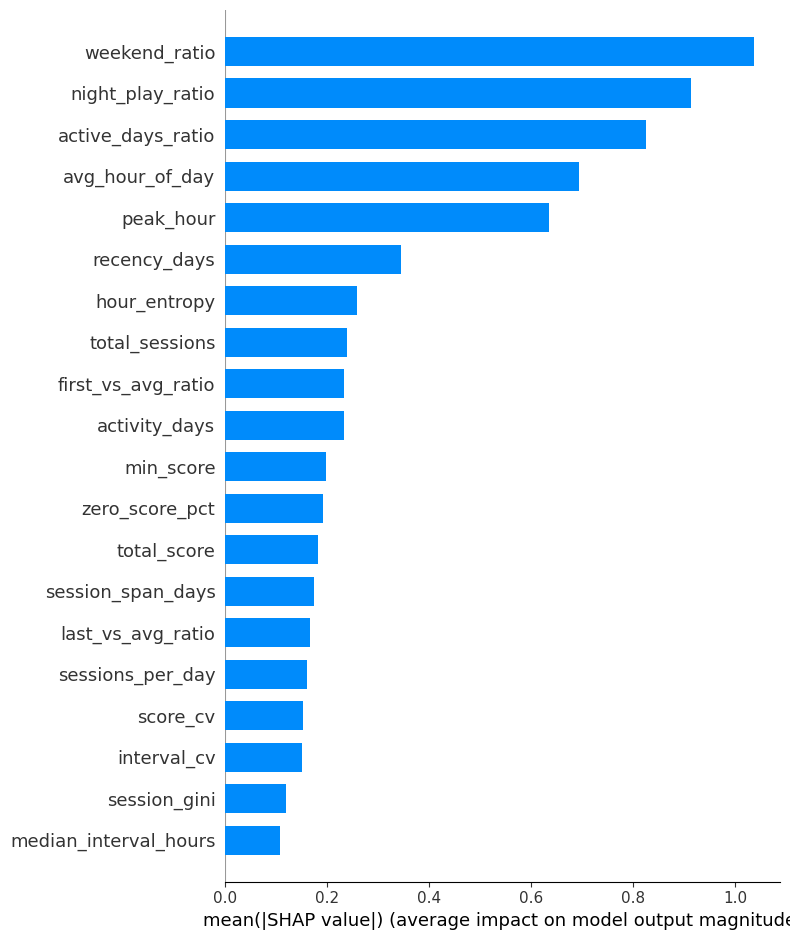

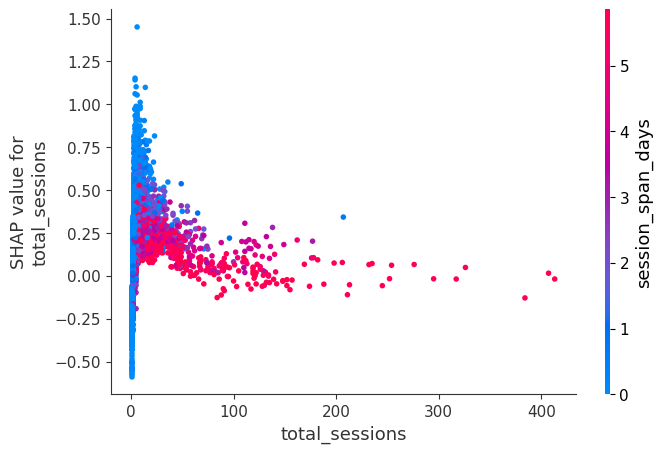

In [623]:
print("\n=== SHAP Analysis for Tuned CatBoost ===")

# Initialize SHAP
explainer = shap.TreeExplainer(best_cat)

# Compute SHAP values on test set
shap_values = explainer.shap_values(X_test)

# Summary plot (violin)
shap.summary_plot(shap_values, X_test, plot_type="violin")

# Bar plot (importance)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Example dependence plot for top feature
top_feature = X_test.columns[0]
shap.dependence_plot(top_feature, shap_values, X_test)

# Example local explanation
i = 0
shap.force_plot(explainer.expected_value, shap_values[i], X_test.iloc[i])
